In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("perrin-freres-monthly-champagne-.csv")

In [15]:
df.head()

,Month,Perrin Freres monthly champagne sales millions ?64-?72
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


In [16]:
df.columns=['Month','Sales'] #renamed the columns

In [17]:
df.head()

,Month,Sales
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


In [18]:
df.isnull().sum()

Month    1
Sales    2
dtype: int64

In [19]:
df.tail()

,Month,Sales
102,1972-07,4298.0
103,1972-08,1413.0
104,1972-09,5877.0
105,NaN,NaN
106,Perrin Freres monthly champagne sales millions...,NaN


In [20]:
df.dropna(inplace=True) #permant change

In [21]:
df.tail() # bottom last records (last 5 records)

,Month,Sales
100,1972-05,4618.0
101,1972-06,5312.0
102,1972-07,4298.0
103,1972-08,1413.0
104,1972-09,5877.0


In [22]:
df.shape

(105, 2)

In [23]:
df.isnull().sum()

Month    0
Sales    0
dtype: int64

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 105 entries, 0 to 104
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Month   105 non-null    object 
 1   Sales   105 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.5+ KB


In [ ]:
# convert yoour date time obejct into date time column propery

In [25]:
pd.to_datetime(df.Month)

0     1964-01-01
1     1964-02-01
2     1964-03-01
3     1964-04-01
4     1964-05-01
         ...    
100   1972-05-01
101   1972-06-01
102   1972-07-01
103   1972-08-01
104   1972-09-01
Name: Month, Length: 105, dtype: datetime64[ns]

In [27]:
df['Month'] = pd.to_datetime(df.Month)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 105 entries, 0 to 104
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Month   105 non-null    datetime64[ns]
 1   Sales   105 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.5 KB


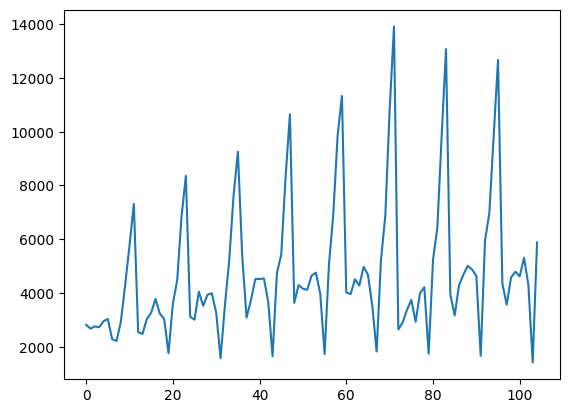

In [29]:
plt.plot(df.Sales)

In [30]:
df.set_index("Month",inplace=True)

In [31]:
df

,Sales
Month,
1964-01-01,2815.0
1964-02-01,2672.0
1964-03-01,2755.0
1964-04-01,2721.0
1964-05-01,2946.0
...,...
1972-05-01,4618.0
1972-06-01,5312.0
1972-07-01,4298.0


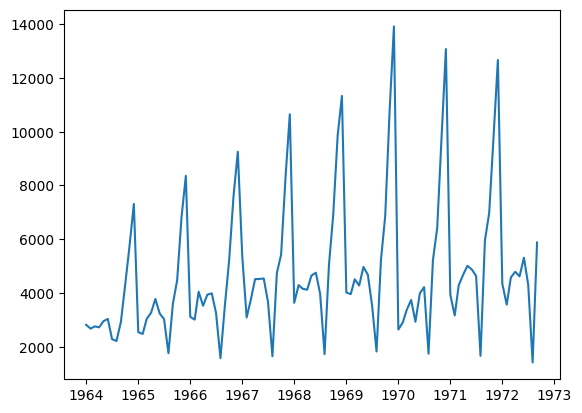

In [32]:
plt.plot(df.Sales)

In [34]:
!pip install statsmodels 

     ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
     ---------------------------------------- 0.1/9.1 MB 3.3 MB/s eta 0:00:03
     - -------------------------------------- 0.4/9.1 MB 4.3 MB/s eta 0:00:03
     ----- ---------------------------------- 1.2/9.1 MB 8.5 MB/s eta 0:00:01
     ------------- -------------------------- 3.1/9.1 MB 16.8 MB/s eta 0:00:01
     ----------------- ---------------------- 4.0/9.1 MB 18.3 MB/s eta 0:00:01
     -------------------------- ------------- 6.1/9.1 MB 21.6 MB/s eta 0:00:01
     ---------------------------- ----------- 6.4/9.1 MB 20.5 MB/s eta 0:00:01
     ------------------------------------- -- 8.6/9.1 MB 22.8 MB/s eta 0:00:01
     ---------------------------------------  9.1/9.1 MB 22.5 MB/s eta 0:00:01
     ---------------------------------------  9.1/9.1 MB 22.5 MB/s eta 0:00:01
     ---------------------------------------- 9.1/9.1 MB 19.5 MB/s eta 0:00:00
     ---------------------------------------- 0.0/233.8 kB ? et


[notice] A new release of pip is available: 23.0.1 -> 23.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from statsmodels.tsa.stattools import adfuller

In [36]:
result = adfuller(df['Sales'])

In [37]:
result #pvalue # 1 index

(-1.8335930563276297,
 0.3639157716602417,
 11,
 93,
 {'1%': -3.502704609582561,
  '5%': -2.8931578098779522,
  '10%': -2.583636712914788},
 1478.4633060594724)

In [39]:
p_value = result[1]

In [40]:
if p_value<=0.05:
    print("Rejecting the NUll hypothesis---> Series is Stat")
else:
    print("Not Rejecting the NUll hypothesis---> Series is not Stat")

Not Rejecting the NUll hypothesis---> Series is not Stat


In [41]:
from random import gauss
from random import seed
from pandas import Series
from pandas.plotting import autocorrelation_plot
# seed random number generator
seed(1)
# create white noise series
series = [gauss(0.0, 1.0) for i in range(1000)]
series = Series(series)

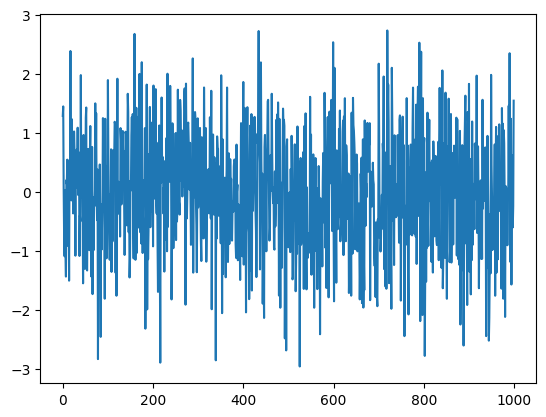

In [43]:
plt.plot(series)

In [42]:
result = adfuller(series)
if result[1]<=0.05:
    print("Rejecting null hypothesis--->Series is Stationary")
else:
    print("Not Rejecting null hypothesis--->Series is not Stationary")

Rejecting null hypothesis--->Series is Stationary


In [44]:
result[1]

0.0

# Non Stationary - Stat

# Differencing

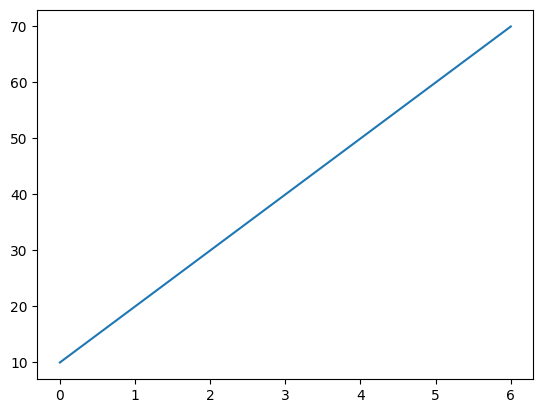

In [45]:
plt.plot([10,20,30,40,50,60,70])

In [46]:
sr1 = pd.Series([10,20,30,40,50,60,70])

In [49]:
sr2 = sr1.shift(1)

In [50]:
sr2

0     NaN
1    10.0
2    20.0
3    30.0
4    40.0
5    50.0
6    60.0
dtype: float64

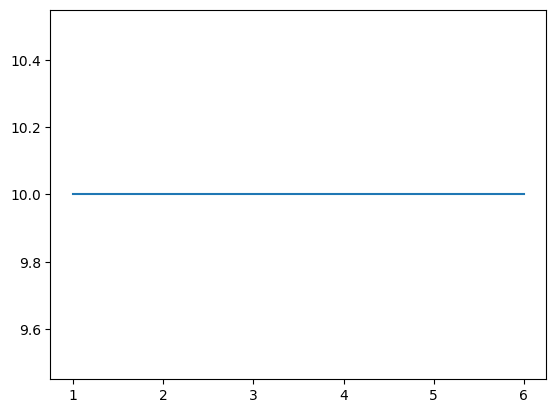

In [52]:
plt.plot(sr1-sr2)

In [54]:
df_diff = df['Sales'] -df['Sales'].shift(1) #1st order difference

In [59]:
df['Sales']

Month
1964-01-01    2815.0
1964-02-01    2672.0
1964-03-01    2755.0
1964-04-01    2721.0
1964-05-01    2946.0
               ...  
1972-05-01    4618.0
1972-06-01    5312.0
1972-07-01    4298.0
1972-08-01    1413.0
1972-09-01    5877.0
Name: Sales, Length: 105, dtype: float64

In [55]:
df_diff

Month
1964-01-01       NaN
1964-02-01    -143.0
1964-03-01      83.0
1964-04-01     -34.0
1964-05-01     225.0
               ...  
1972-05-01    -170.0
1972-06-01     694.0
1972-07-01   -1014.0
1972-08-01   -2885.0
1972-09-01    4464.0
Name: Sales, Length: 105, dtype: float64

In [57]:
result = adfuller(df_diff.dropna())
if result[1]<=0.05:
    print("Rejecting null hypothesis--->Series is Stationary")
else:
    print("Not Rejecting null hypothesis--->Series is not Stationary")

Rejecting null hypothesis--->Series is Stationary


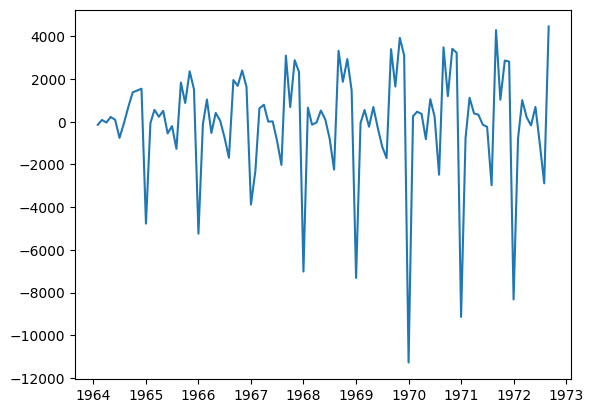

In [58]:
plt.plot( df['Sales']-df['Sales'].shift(1))

# box cox 